# Active Dwarf Galaxy Database: grahspj SED Fits and $\alpha_{\mathrm{OX}}$

This notebook downloads the Active Dwarf Galaxy Database catalog from GitHub, keeps sources with detected X-ray luminosities (`upper_limit_flag == False`), fits each usable AGN SED with `grahspj`, and compares the inferred UV-to-X-ray slope against the $L_{2500}$ relation.

The UV luminosity is inferred from the fitted rest-frame AGN component at 2500 A. The X-ray monochromatic luminosity at 2 keV is inferred from the catalog 0.5-8 keV luminosity assuming a power-law photon index.

## Setup

This notebook assumes:
- you are running from the `notebooks/` directory of this repository
- the `sed` conda environment or equivalent dependencies are available
- a valid DSPS SSP file is available as a sibling checkout at `../../jaxqsofit/tempdata.h5`

The default fitting loop uses MAP optimization (`fit_method="optax"`) so the full catalog run is tractable. Increase `OPTAX_STEPS` or switch to `optax+nuts` for a smaller subset if you need posterior uncertainties.

In [7]:
from pathlib import Path
import sys
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from tqdm.auto import tqdm

project_root = Path.cwd().resolve().parent
src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from grahspj.config import AGNConfig, FilterSet, FitConfig, GalaxyConfig, InferenceConfig, LikelihoodConfig, Observation, PhotometryData
from grahspj.core import GRAHSPJ
from grahspj.mplstyle import style_path

plt.style.use(style_path())


In [8]:
CATALOG_URL = "https://raw.githubusercontent.com/erikwasleske/Active-Dwarf-Galaxy-Database/main/ADGD_v1.fits"
data_dir = project_root / "data" / "adgd"
data_dir.mkdir(parents=True, exist_ok=True)
catalog_path = data_dir / "ADGD_v1.fits"

if not catalog_path.is_file():
    print("Downloading", CATALOG_URL)
    urlretrieve(CATALOG_URL, catalog_path)

catalog = Table.read(catalog_path)
print(f"Catalog rows: {len(catalog):,}")
catalog[:3]


Catalog rows: 702


ID,RA,DEC,Source,Literature_Selection_Method,Mass,Redshift,g_band,r_band,L_Ha_na,L_Ha_na_err,L_Hb_na,L_Hb_na_err,L_OIII5007,L_OIII5007_err,L_NII6585,L_NII6585_err,L_SII,L_SII_err,L_OI6300,L_OI6300_err,L_HeII,L_HeII_err,L_FeX_na,L_FeX_na_err,BPT_Classification,OI_Classification,SII_Classification,HeII_Classification,FWHM_Ha_br,FWHM_Ha_br_err,FWHM_Hb_br,FWHM_Hb_br_err,L_Ha_br,L_Ha_br_err,L_Hb_br,L_Hb_br_err,M_BH,M_BH_err,w1mpro,w1sigmpro,w2mpro,w2sigmpro,w3mpro,w3sigmpro,w4mpro,w4sigmpro,L_WISE1,L_lowerr_WISE1,L_uperr_WISE1,L_WISE2,L_lowerr_WISE2,L_uperr_WISE2,L_WISE3,L_lowerr_WISE3,L_uperr_WISE3,L_WISE4,L_lowerr_WISE4,L_uperr_WISE4,Jarrett_Classification,Stern_Classification,Hviding_Classification,WISE_Class,upper_limit_flag_cxo,upper_limit_flag_xmm,L_0.2-12_FLIX,L_0.5-8,L_0.5-8_lo_limit,L_0.5-8_hi_limit,upper_limit_flag,L_NUV,L_NUV_uperr,L_NUV_lowerr,L_FUV,L_FUV_uperr,L_FUV_lowerr,log(SFR)_KE_12_opt,log(SFR)_KE_12_nuv,log(SFR)_KE_12_fuv,L_0.5-8_expect_XRB,L_0.5-8_expect_XRB_lo_limit,L_0.5-8_expect_XRB_hi_limit,L_expected_Gas,L_expected_Gas_lo_limit,L_expected_Gas__hi_limit,Npoints,Baseline,MedMag_r,Std_r,SigVar_r,SigQSO_r,SigNotQSO_r,cModelMag_u,cModelMagErr_u,cModelMag_g,cModelMagErr_g,cModelMag_r,cModelMagErr_r,cModelMag_i,cModelMagErr_i,cModelMag_z,cModelMagErr_z,extinction_u,extinction_g,extinction_r,extinction_i,extinction_z,RA_sdss,DEC_sdss,RAerr_sdss,DECerr_sdss,clean_sdss,type_sdss,RA_wise,DEC_wise,RAunc_wise,DECunc_wise,w1mpro_new,w1sigmpro_new,w2mpro_new,w2sigmpro_new,w3mpro_new,w3sigmpro_new,w4mpro_new,w4sigmpro_new,dist_wise,RA_galex,DEC_galex,NUVmag,e_NUVmag,FUVmag,e_FUVmag,eBV_galex,raMean,decMean,raMeanErr,decMeanErr,gMeanPSFMag,gMeanPSFMagErr,gMeanApMag,gMeanApMagErr,gFlags,rMeanPSFMag,rMeanPSFMagErr,rMeanApMag,rMeanApMagErr,rFlags,iMeanPSFMag,iMeanPSFMagErr,iMeanApMag,iMeanApMagErr,iFlags,zMeanPSFMag,zMeanPSFMagErr,zMeanApMag,zMeanApMagErr,zFlags,yMeanPSFMag,yMeanPSFMagErr,yMeanApMag,yMeanApMagErr,yFlags,RA_ukidss,DEC_ukidss,RAunc_ukidss,DECunc_ukidss,yAperMag3,yAperMag3Err,j_1AperMag3,j_1AperMag3Err,hAperMag3,hAperMag3Err,kAperMag3,kAperMag3Err,yPetroMag,yPetroMagErr,j_1PetroMag,j_1PetroMagErr,hPetroMag,hPetroMagErr,kPetroMag,kPetroMagErr,yPsfMag,yPsfMagErr,j_1PsfMag,j_1PsfMagErr,hPsfMag,hPsfMagErr,kPsfMag,kPsfMagErr,eBV_ukidss,dist_ukidss,bayes.agn.EBV,bayes.agn.EBV_err,bayes.agn.fracAGN,bayes.agn.fracAGN_err,bayes.stellar.metallicity,bayes.stellar.metallicity_err,bayes.agn.L_6um,bayes.agn.L_6um_err,bayes.agn.accretion_power,bayes.agn.accretion_power_err,bayes.agn.intrin_Lnu_2500A_30deg,bayes.agn.intrin_Lnu_2500A_30deg_err,bayes.agn.luminosity,bayes.agn.luminosity_err,bayes.dust.luminosity,bayes.dust.luminosity_err,bayes.sfh.sfr,bayes.sfh.sfr_err,bayes.sfh.sfr100Myrs,bayes.sfh.sfr100Myrs_err,bayes.sfh.sfr10Myrs,bayes.sfh.sfr10Myrs_err,bayes.stellar.lum,bayes.stellar.lum_err,bayes.H_2mass,bayes.H_2mass_err,bayes.J_2mass,bayes.J_2mass_err,bayes.Ks_2mass,bayes.Ks_2mass_err,bayes.WISE1,bayes.WISE1_err,bayes.WISE2,bayes.WISE2_err,bayes.WISE3,bayes.WISE3_err,bayes.WISE4,bayes.WISE4_err,bayes.galex.FUV,bayes.galex.FUV_err,bayes.galex.NUV,bayes.galex.NUV_err,bayes.sdss.gp,bayes.sdss.gp_err,bayes.sdss.ip,bayes.sdss.ip_err,bayes.sdss.rp,bayes.sdss.rp_err,bayes.sdss.up,bayes.sdss.up_err,bayes.sdss.zp,bayes.sdss.zp_err,bayes.ukirt.H,bayes.ukirt.H_err,bayes.ukirt.J,bayes.ukirt.J_err,bayes.ukirt.Ks,bayes.ukirt.Ks_err,bayes.ukirt.Y,bayes.ukirt.Y_err,bayes.xray_boxcar_0p5to8keV,bayes.xray_boxcar_0p5to8keV_err,Selection_Results,bayes.H_2mass_L,bayes.ukirt.J_L,bayes.ukirt.H_L,bayes.sdss.zp_L,bayes.sdss.ip_L,bayes.sdss.rp_L,bayes.sdss.gp_L,bayes.sdss.up_L,bayes.galex.NUV_L,bayes.galex.FUV_L,bayes.WISE4_L,bayes.WISE3_L,bayes.WISE2_L,bayes.WISE1_L,bayes.Ks_2mass_L,bayes.J_2mass_L,bayes.ukirt.Ks_L,bayes.ukirt.Y_L,BPT,[OI]-Seyfert,[OI]-LINER,[SII]-Seyfert,[SII]-LINER,[HeII],broad-line,IR,X-ray,Var.
bytes23,float64,float64,bytes85,bytes47,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float6

In [9]:
def finite_positive(values):
    arr = np.asarray(values, dtype=float)
    return np.isfinite(arr) & (arr > 0.0)

detected_xray = (
    (~np.asarray(catalog["upper_limit_flag"], dtype=bool))
    & finite_positive(catalog["L_0.5-8"])
    & finite_positive(catalog["Redshift"])
)
adgd = catalog[detected_xray]

print(f"X-ray detections with upper_limit_flag == False: {len(adgd):,}")
adgd[["ID", "RA", "DEC", "Redshift", "Mass", "L_0.5-8", "upper_limit_flag"]][:10]


X-ray detections with upper_limit_flag == False: 95


ID,RA,DEC,Redshift,Mass,L_0.5-8,upper_limit_flag
bytes23,float64,float64,float64,float64,float64,bool
NSA89394_v0,186.45361724196673,33.546866450115886,0.0011,9.1,2.897902382367199e+39,False
NSA31028_v0,192.4911599021908,5.311374158030602,0.0022,9.2,1.514484724175399e+38,False
SDSSJ153704.18+551550.5,234.26737645383,55.26407154177,0.0024,7.369999885559082,2.542425097174142e+39,False
J122112.83+182257.7,185.30344,18.382707,0.003,8.03,3.471625904477011e+38,False
NSA86723_v0,200.48527509605609,38.73456067790942,0.0033,9.46,1.025407433981709e+37,False
NSA166312_v0,234.1329261767468,16.44045529079599,0.0064,9.07,1.1769474046018408e+40,False
NSA27397_v0,167.3016574460881,61.396408481379154,0.0067,8.91,2.7621217400156893e+38,False
NSA161692_v0,186.27337288977782,5.329118636635182,0.0068,9.29,6.173327583526844e+37,False
Sartori8012,126.51829166666666,45.96763888888889,0.0071,9.16,2.001149733163793e+40,False


## Catalog Photometry

The catalog already includes homogeneous survey photometry used for SED modeling in the ADGD work. This notebook uses GALEX FUV/NUV, SDSS ugriz, UKIDSS DR11PLUS/WFCAM YJHK, and WISE W1-W4 when available.

SDSS and GALEX magnitudes are treated as AB. WISE and UKIDSS magnitudes are Vega; UKIDSS is converted to AB with standard WFCAM offsets before converting to flux density. The UKIDSS WFCAM filter curves are vendored in `grahspj` because they are not available through `speclite`.



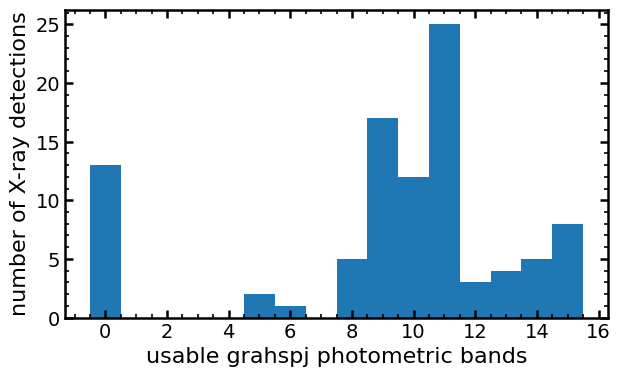

Sources with >= 5 usable bands: 82
Sources with usable UKIDSS DR11PLUS photometry: 25


In [10]:
WISE_ZEROPOINT_JY = {
    "W1": 309.540,
    "W2": 171.787,
    "W3": 31.674,
    "W4": 8.363,
}

UKIDSS_VEGA_TO_AB = {
    "ukirt.wfcam.Y": 0.634,
    "ukirt.wfcam.J": 0.938,
    "ukirt.wfcam.H": 1.379,
    "ukirt.wfcam.K": 1.900,
}

UKIDSS_EBV_TO_A_LAMBDA = {
    "ukirt.wfcam.Y": 1.206,
    "ukirt.wfcam.J": 0.866,
    "ukirt.wfcam.H": 0.567,
    "ukirt.wfcam.K": 0.366,
}

INVALID_MAG_LIMIT = 90.0

PHOTOMETRY_COLUMNS = [
    {"filter_name": "FUV_galex", "speclite_name": "galex-fuv", "mag": "FUVmag", "err": "e_FUVmag", "system": "ab", "psf_fwhm_arcsec": 4.3},
    {"filter_name": "NUV_galex", "speclite_name": "galex-nuv", "mag": "NUVmag", "err": "e_NUVmag", "system": "ab", "psf_fwhm_arcsec": 5.3},
    {"filter_name": "u_sdss", "speclite_name": "sdss2010-u", "mag": "cModelMag_u", "err": "cModelMagErr_u", "ext": "extinction_u", "system": "ab", "psf_fwhm_arcsec": 1.53},
    {"filter_name": "g_sdss", "speclite_name": "sdss2010-g", "mag": "cModelMag_g", "err": "cModelMagErr_g", "ext": "extinction_g", "system": "ab", "psf_fwhm_arcsec": 1.44},
    {"filter_name": "r_sdss", "speclite_name": "sdss2010-r", "mag": "cModelMag_r", "err": "cModelMagErr_r", "ext": "extinction_r", "system": "ab", "psf_fwhm_arcsec": 1.32},
    {"filter_name": "i_sdss", "speclite_name": "sdss2010-i", "mag": "cModelMag_i", "err": "cModelMagErr_i", "ext": "extinction_i", "system": "ab", "psf_fwhm_arcsec": 1.26},
    {"filter_name": "z_sdss", "speclite_name": "sdss2010-z", "mag": "cModelMag_z", "err": "cModelMagErr_z", "ext": "extinction_z", "system": "ab", "psf_fwhm_arcsec": 1.29},
    {"filter_name": "ukirt.wfcam.Y", "mag": "yAperMag3", "err": "yAperMag3Err", "ext_ebv": "eBV_ukidss", "system": "ukidss_vega", "psf_fwhm_arcsec": 0.8},
    {"filter_name": "ukirt.wfcam.J", "mag": "j_1AperMag3", "err": "j_1AperMag3Err", "ext_ebv": "eBV_ukidss", "system": "ukidss_vega", "psf_fwhm_arcsec": 0.8},
    {"filter_name": "ukirt.wfcam.H", "mag": "hAperMag3", "err": "hAperMag3Err", "ext_ebv": "eBV_ukidss", "system": "ukidss_vega", "psf_fwhm_arcsec": 0.8},
    {"filter_name": "ukirt.wfcam.K", "mag": "kAperMag3", "err": "kAperMag3Err", "ext_ebv": "eBV_ukidss", "system": "ukidss_vega", "psf_fwhm_arcsec": 0.8},
    {"filter_name": "W1", "speclite_name": "wise2010-W1", "mag": "w1mpro_new", "err": "w1sigmpro_new", "system": "vega", "psf_fwhm_arcsec": 6.08},
    {"filter_name": "W2", "speclite_name": "wise2010-W2", "mag": "w2mpro_new", "err": "w2sigmpro_new", "system": "vega", "psf_fwhm_arcsec": 6.84},
    {"filter_name": "W3", "speclite_name": "wise2010-W3", "mag": "w3mpro_new", "err": "w3sigmpro_new", "system": "vega", "psf_fwhm_arcsec": 7.36},
    {"filter_name": "W4", "speclite_name": "wise2010-W4", "mag": "w4mpro_new", "err": "w4sigmpro_new", "system": "vega", "psf_fwhm_arcsec": 11.99},
]

def as_float(value):
    try:
        out = float(value)
    except Exception:
        return np.nan
    if not np.isfinite(out) or abs(out) >= 1.0e10:
        return np.nan
    return out

def valid_mag_and_error(mag, mag_err):
    return (
        np.isfinite(mag)
        and np.isfinite(mag_err)
        and 0.0 < mag < INVALID_MAG_LIMIT
        and 0.0 < mag_err < INVALID_MAG_LIMIT
    )

def mag_to_flux_mjy(mag, system, filter_name):
    if system == "ab":
        mag_ab = mag
    elif system == "ukidss_vega":
        mag_ab = mag + UKIDSS_VEGA_TO_AB[filter_name]
    elif system == "vega":
        return WISE_ZEROPOINT_JY[filter_name] * 1.0e3 * 10.0 ** (-0.4 * mag)
    else:
        raise ValueError(f"Unknown magnitude system: {system}")
    return 3631.0e3 * 10.0 ** (-0.4 * mag_ab)

def magerr_to_fluxerr_mjy(flux_mjy, mag_err):
    return abs(flux_mjy) * np.log(10.0) * 0.4 * mag_err

def photometry_for_row(row, min_frac_err=0.03):
    rows = []
    for spec in PHOTOMETRY_COLUMNS:
        mag = as_float(row[spec["mag"]])
        mag_err = as_float(row[spec["err"]])
        if not valid_mag_and_error(mag, mag_err):
            continue
        if "ext" in spec:
            mag = mag - max(as_float(row[spec["ext"]]), 0.0)
        if "ext_ebv" in spec:
            ebv = as_float(row[spec["ext_ebv"]])
            if np.isfinite(ebv) and ebv > 0.0:
                mag = mag - UKIDSS_EBV_TO_A_LAMBDA[spec["filter_name"]] * ebv
        flux_mjy = mag_to_flux_mjy(mag, spec["system"], spec["filter_name"])
        err_mjy = max(magerr_to_fluxerr_mjy(flux_mjy, mag_err), min_frac_err * abs(flux_mjy))
        if not np.isfinite(flux_mjy) or not np.isfinite(err_mjy) or flux_mjy <= 0.0 or err_mjy <= 0.0:
            continue
        item = {
            "filter_name": spec["filter_name"],
            "flux_mjy": flux_mjy,
            "err_mjy": err_mjy,
            "psf_fwhm_arcsec": spec["psf_fwhm_arcsec"],
        }
        if "speclite_name" in spec:
            item["speclite_name"] = spec["speclite_name"]
        rows.append(item)
    return rows

phot_counts = np.array([len(photometry_for_row(row)) for row in adgd])
ukidss_counts = np.array([
    sum(item["filter_name"].startswith("ukirt.wfcam.") for item in photometry_for_row(row))
    for row in adgd
])
plt.figure(figsize=(7, 4))
plt.hist(phot_counts, bins=np.arange(phot_counts.max() + 2) - 0.5)
plt.xlabel("usable grahspj photometric bands")
plt.ylabel("number of X-ray detections")
plt.show()

MIN_BANDS_TO_FIT = 5
fit_rows = adgd[phot_counts >= MIN_BANDS_TO_FIT]
print(f"Sources with >= {MIN_BANDS_TO_FIT} usable bands: {len(fit_rows):,}")
print(f"Sources with usable UKIDSS DR11PLUS photometry: {np.count_nonzero(ukidss_counts):,}")




## Fit Configuration

`MAX_SOURCES = None` runs all usable X-ray detections. Set it to a small integer while developing the notebook.

In [11]:
dsps_ssp_fn = project_root.parent / "jaxqsofit" / "tempdata.h5"
assert dsps_ssp_fn.is_file(), f"DSPS SSP file not found: {dsps_ssp_fn}"

MAX_SOURCES = 20
FIT_METHOD = "optax+nuts"
OPTAX_STEPS = 1500
OPTAX_LR = 5e-3

def source_id(row):
    return str(row["ID"]).strip().replace(" ", "_").replace("/", "_")

def build_fit_config(row):
    phot_rows = photometry_for_row(row)
    mass = as_float(row["Mass"])
    mass_loc = mass if np.isfinite(mass) else 9.0
    return FitConfig(
        observation=Observation(
            object_id=source_id(row),
            redshift=float(row["Redshift"]),
            fit_redshift=False,
            ra=as_float(row["RA"]),
            dec=as_float(row["DEC"]),
        ),
        photometry=PhotometryData(
            filter_names=[item["filter_name"] for item in phot_rows],
            fluxes=[item["flux_mjy"] for item in phot_rows],
            errors=[item["err_mjy"] for item in phot_rows],
            is_upper_limit=[False] * len(phot_rows),
            psf_fwhm_arcsec=[item["psf_fwhm_arcsec"] for item in phot_rows],
        ),
        filters=FilterSet(
            speclite_names={item["filter_name"]: item["speclite_name"] for item in phot_rows if "speclite_name" in item},
            use_grahsp_database=False,
        ),
        galaxy=GalaxyConfig(
            dsps_ssp_fn=str(dsps_ssp_fn),
            n_wave=768,
            sfh_n_steps=48,
        ),
        agn=AGNConfig(agn_type=1, fit_agn=True),
        likelihood=LikelihoodConfig(use_host_capture_model=False),
        inference=InferenceConfig(map_steps=OPTAX_STEPS, learning_rate=OPTAX_LR, seed=0),
        prior_config={
            "log_stellar_mass": {"loc": mass_loc, "scale": 2.0},
        },
    )

rows_to_fit = fit_rows[:MAX_SOURCES] if MAX_SOURCES is not None else fit_rows
print(f"Will fit {len(rows_to_fit):,} sources")



Will fit 20 sources


In [ ]:
fitters = {}
fit_summaries = []
failed = []

for row in tqdm(rows_to_fit, desc="grahspj fits"):
    sid = source_id(row)
    try:
        cfg = build_fit_config(row)
        fitter = GRAHSPJ(cfg)
        fitter.fit(
            fit_method=FIT_METHOD,
            prior_config=cfg.prior_config,
            dsps_ssp_fn=cfg.galaxy.dsps_ssp_fn,
            optax_steps=cfg.inference.map_steps,
            optax_lr=cfg.inference.learning_rate,
            plot_fig=True,
            save_fig=False,
            save_result=False,
            progress_bar=False,
        )
        fitters[sid] = fitter
        fit_summaries.append({"ID": sid, "n_bands": len(cfg.photometry.filter_names), **fitter.summary()})
    except Exception as exc:
        failed.append({"ID": sid, "error": repr(exc)})

summary_table = Table(rows=fit_summaries)
failed_table = Table(rows=failed) if failed else Table(names=("ID", "error"))

print(f"Successful fits: {len(summary_table):,}")
print(f"Failed fits: {len(failed_table):,}")
summary_table[:5]


grahspj fits:   0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
failed_table[:10]


## Derive $L_{2500}$ and $\alpha_{\mathrm{OX}}$

$\alpha_{\mathrm{OX}} = 0.3838 \log_{10}(L_{\nu,2\,\mathrm{keV}} / L_{\nu,2500\,\mathring{A}})$.

The catalog provides integrated 0.5-8 keV luminosity. The conversion to 2 keV monochromatic luminosity assumes $L_E \propto E^{1-\Gamma}$ with `PHOTON_INDEX = 1.8`.

In [ ]:
C_A_PER_S = 2.99792458e18
H_KEV_S = 4.135667696e-18
PHOTON_INDEX = 1.8
UV_COMPONENT_SITE = "agn_rest_sed"

row_by_id = {source_id(row): row for row in rows_to_fit}

def median_site(pred, key):
    arr = np.asarray(pred[key], dtype=float)
    return np.nanmedian(arr, axis=0) if arr.ndim > 1 else arr

def lnu_2500_from_fit(fitter, component_site=UV_COMPONENT_SITE):
    pred = fitter.predict()
    rest_wave = median_site(pred, "rest_wave")
    component_llambda_w_a = median_site(pred, component_site)
    llambda_2500_w_a = float(np.interp(2500.0, rest_wave, component_llambda_w_a, left=np.nan, right=np.nan))
    return llambda_2500_w_a * 1.0e7 * 2500.0**2 / C_A_PER_S

def lnu_2kev_from_lx(lx_erg_s, gamma=PHOTON_INDEX, e1=0.5, e2=8.0, e0=2.0):
    lx = float(lx_erg_s)
    if np.isclose(gamma, 2.0):
        norm = lx / np.log(e2 / e1)
    else:
        norm = lx * (2.0 - gamma) / (e2 ** (2.0 - gamma) - e1 ** (2.0 - gamma))
    l_e_2kev = norm * e0 ** (1.0 - gamma)
    return l_e_2kev * H_KEV_S

alpha_rows = []
for sid, fitter in tqdm(fitters.items(), desc="alpha_ox"):
    row = row_by_id[sid]
    lnu_2500 = lnu_2500_from_fit(fitter)
    lnu_2kev = lnu_2kev_from_lx(row["L_0.5-8"])
    if not (np.isfinite(lnu_2500) and np.isfinite(lnu_2kev) and lnu_2500 > 0.0 and lnu_2kev > 0.0):
        continue
    alpha_ox = 0.3838 * np.log10(lnu_2kev / lnu_2500)
    alpha_rows.append({
        "ID": sid,
        "Redshift": float(row["Redshift"]),
        "Mass": as_float(row["Mass"]),
        "L_0.5-8": float(row["L_0.5-8"]),
        "log_Lnu_2500": np.log10(lnu_2500),
        "log_Lnu_2kev": np.log10(lnu_2kev),
        "alpha_ox": alpha_ox,
    })

alpha_table = Table(rows=alpha_rows)
print(f"Rows with finite alpha_ox: {len(alpha_table):,}")
alpha_table[:10]


In [ ]:
def just_relation_alpha_ox(log_l2500):
    # Just et al. 2007, alpha_ox = (-0.137) log Lnu(2500 A) + 2.638
    return -0.137 * np.asarray(log_l2500, dtype=float) + 2.638

fig, ax = plt.subplots(figsize=(7, 5))
x = np.asarray(alpha_table["log_Lnu_2500"], dtype=float)
y = np.asarray(alpha_table["alpha_ox"], dtype=float)
sc = ax.scatter(
    x,
    y,
    c=np.asarray(alpha_table["Mass"], dtype=float),
    cmap="viridis",
    s=34,
    alpha=0.85,
    edgecolor="none",
)

if len(x):
    xx = np.linspace(np.nanmin(x) - 0.2, np.nanmax(x) + 0.2, 200)
    ax.plot(xx, just_relation_alpha_ox(xx), color="k", lw=2, label="Just+2007")

ax.set_xlabel(r"$\log_{10} L_{\nu}(2500\,\AA)$ [erg s$^{-1}$ Hz$^{-1}$]")
ax.set_ylabel(r"$\alpha_{\mathrm{OX}}$")
ax.legend(frameon=False)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$\log_{10} M_\star / M_\odot$")
plt.show()


In [ ]:
output_path = data_dir / "adgd_grahspj_alpha_ox.ecsv"
alpha_table.write(output_path, overwrite=True)
print("Wrote", output_path)


## Notes

- The plotted UV luminosity uses `UV_COMPONENT_SITE = "agn_rest_sed"`. Use `"disk_rest_sed"` if you want only the fitted disk continuum at 2500 A.
- The X-ray conversion assumes `PHOTON_INDEX = 1.8`. Changing that value shifts all inferred $L_{\nu,2\,\mathrm{keV}}$ values coherently.
- The ADGD catalog includes CIGALE-derived `bayes.agn.intrin_Lnu_2500A_30deg`; this notebook does not use it for the main plot because the requested UV luminosity is inferred from the `grahspj` AGN component.
